# Self-Validating Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

## Execution Notebook

This notebook provides an interface to the self-validating Bayesian optimization system.

**All model code is in Python modules under `src/`:**
- `config.py` — All tunable parameters (bounds, feature settings, plot style)
- `features.py` — Feature engineering and smart hybrid selection
- `optimizer.py` — Base Cu3VS4Optimizer with GP models
- `selfvalidating.py` — Self-validation system with error learning
- `experiment_store.py` — Experiment and recommendation persistence
- `diagnostics.py` — LOO-CV, VIF, calibration, convergence metrics
- `visualization.py` — All plotting functions
- `chemical_constants.py` — Physical/chemical descriptors

**This notebook is just for execution and visualization.**


In [1]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Add src/ to path so the package is importable
import sys
sys.path.insert(0, str(Path("..").resolve() / "src"))

# --- Core ---
from selfvalidating import SelfValidatingOptimizer
from config import COLORS, PUBLICATION_STYLE

# --- Visualization ---
from visualization import (
    plot_recommendation_history,
    plot_parity,
    plot_calibration,
    plot_error_learning_progress,
    plot_error_correction_impact,
    plot_target_achievement,
    plot_feature_importance,
    plot_classifier_calibration,
    plot_collinearity_heatmap,
    plot_dataset_quality_dashboard,
    plot_loo_residuals,
    plot_property_correlations,
    plot_acquisition_slice,
    plot_recommendation_regret,
)

# --- Diagnostics ---
from diagnostics import (
    compare_feature_modes,
    detect_extrapolation,
    diagnose_collinearity,
    print_model_assessment,
    display_recommendations_table,
    get_optimization_convergence_summary,
    print_optimization_convergence_summary,
)

# Set up paths
DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Apply publication plot style from config
plt.rcParams.update(PUBLICATION_STYLE)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ All imports successful!")
print(f"✓ Data directory: {DATA_DIR.resolve()}")
print(f"✓ Output directory: {OUTPUT_DIR.resolve()}")


✓ All imports successful!
✓ Data directory: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/data
✓ Output directory: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/outputs


/Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/src/features.py:360: UserWarning: Bounds round-trip: 305 out-of-bounds values in 500 samples (by param: {'DDT': 159, 'OAm': 146}). The optimizer clamps these, but CHEMICAL_BOUNDS could be tightened to avoid.
  validate_bounds_roundtrip()


## 1. Initialize the Optimizer

This will:
- Load experiments from JSON (or import from CSV if first run)
- Build GP models with improved regularization (alpha=1e-4)
- Load any existing recommendation history
- Initialize error learner (activates after 10 completed recommendations = 5 batches)

In [2]:
# Initialize the self-validating optimizer
# 
# RECOMMENDED: Use 'synthesis' mode — 6 mechanistically orthogonal features
# See docs/FEATURE_MODES.md for details on each mode
#
optimizer = SelfValidatingOptimizer(
    data_dir=DATA_DIR,
    initialize_from_csv=True,  # Only imports if experiments.json doesn't exist
    feature_mode='synthesis'   # RECOMMENDED: synthesis-driven, mechanistic features
)

# Alternative modes (comment out line above and uncomment one below to switch):
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='raw'       # 5 features: just Temp, Time, VOacac, DDT, OAm
# )
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='chemical'  # 6-7 features: derived chemical descriptors only
# )
# 
# optimizer = SelfValidatingOptimizer(
#     data_dir=DATA_DIR,
#     initialize_from_csv=True,
#     feature_mode='hybrid'    # 8 features: raw + chemical (WARNING: severe collinearity)
# )

# Print current status
optimizer.print_status()


Imported 68 experiments from CSV as 'imported' source

Building base optimizer (Cu3VS4Optimizer) on 56 successful experiments...
Building models with 5 features (synthesis mode)...
  Cubic-only regression data: n=49 (of 56 successful)
  Regression models fitted (n=49)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted
  ✓ Base optimizer created (synthesis mode)
  Features: ['Temp', 'Cu_V_ratio', 'S_Metal_ratio', 'Ligand_Metal_ratio', 'log_Time']
[ErrorLearner] Running LOO-CV for calibration warm-start...

Running LOO cross-validation (cubic-only)...
  Size: R²=0.211, RMSE=6.171
  GSD: R²=-0.181, RMSE=0.210
  Squareness: R²=-0.053, RMSE=0.062
[ErrorLearner] Warm-started calibration factors from LOO-CV coverage:
  Size: cal_68=0.69 (target 0.68) → factor=0.980x (underconfident → shrinking)
  GSD: cal_68=0.65 (target 0.68) → factor=1.041x (overconfident → inflating)
  Squareness: cal_68=0.63 (target 0.68) → factor=1.075x (overconfident → inflating)

S

## 1b. Model Diagnostics (Recommended)

Run comprehensive diagnostics to verify model quality before generating recommendations.

This checks:
- **LOO-CV metrics**: R², RMSE, and uncertainty calibration for each property
- **Collinearity (VIF)**: Detects problematic feature correlations
- **Classifier calibration**: Verifies feasibility predictions are well-calibrated
- **Sample size adequacy**: Warns if too few samples per feature

In [3]:
# =============================================================================
# RUN COMPREHENSIVE MODEL DIAGNOSTICS
# =============================================================================

# Full diagnostic report (LOO-CV, collinearity, classifier calibration)
diagnostics = optimizer.full_diagnostics()

# Optional: Compare feature modes
# Uncomment to run (takes ~2-3 minutes as it fits models for each mode)
comparison_df = optimizer.compare_feature_modes(modes=['raw', 'chemical', 'hybrid', 'synthesis'])


COMPREHENSIVE MODEL DIAGNOSTICS

Feature mode: synthesis
Features (5): ['Temp', 'Cu_V_ratio', 'S_Metal_ratio', 'Ligand_Metal_ratio', 'log_Time']
Training samples: 68 total, 56 successful
✓ Samples per feature ratio: 11.2

--- LOO-CV Regression Metrics ---
Size: R²=0.211, RMSE=6.171, Cal_68=0.69 (target: 0.68), Cal_95=0.88 (target: 0.95)
GSD: R²=-0.181, RMSE=0.210, Cal_68=0.65 (target: 0.68), Cal_95=0.92 (target: 0.95)
Squareness: R²=-0.053, RMSE=0.062, Cal_68=0.63 (target: 0.68), Cal_95=0.94 (target: 0.95)

--- Collinearity Diagnostics ---
✓ No severe collinearity detected
           Feature      VIF     Interpretation
        Cu_V_ratio 1.826046 ✓ Low (acceptable)
     S_Metal_ratio 1.461339 ✓ Low (acceptable)
Ligand_Metal_ratio 1.315984 ✓ Low (acceptable)
              Temp 1.159549 ✓ Low (acceptable)
          log_Time 1.157769 ✓ Low (acceptable)

--- Classifier Calibration ---
HasProduct: Brier=0.0298, ECE=0.1524
  ✓ Excellent calibration (Brier < 0.1); High ECE (0.152) suggests m

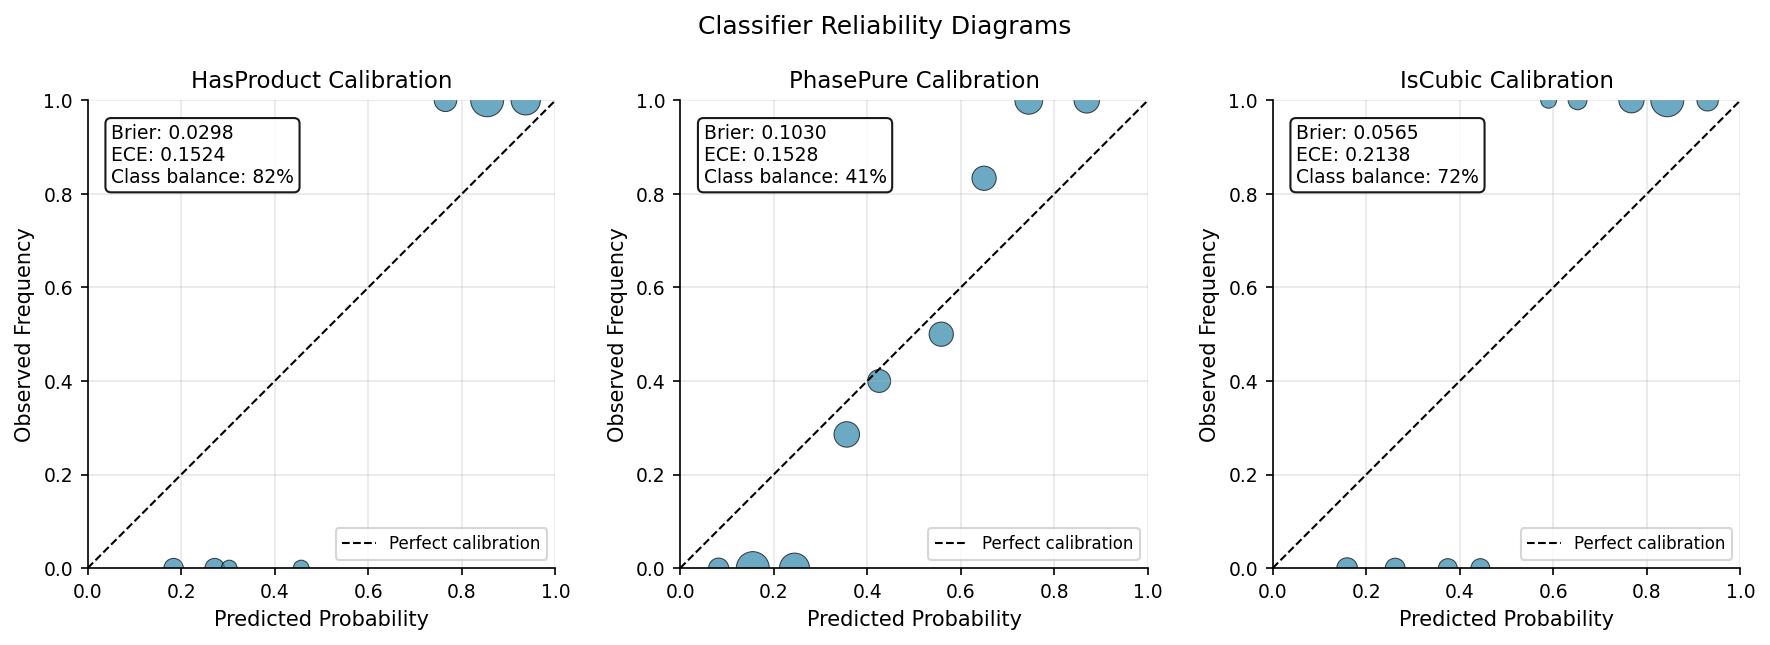

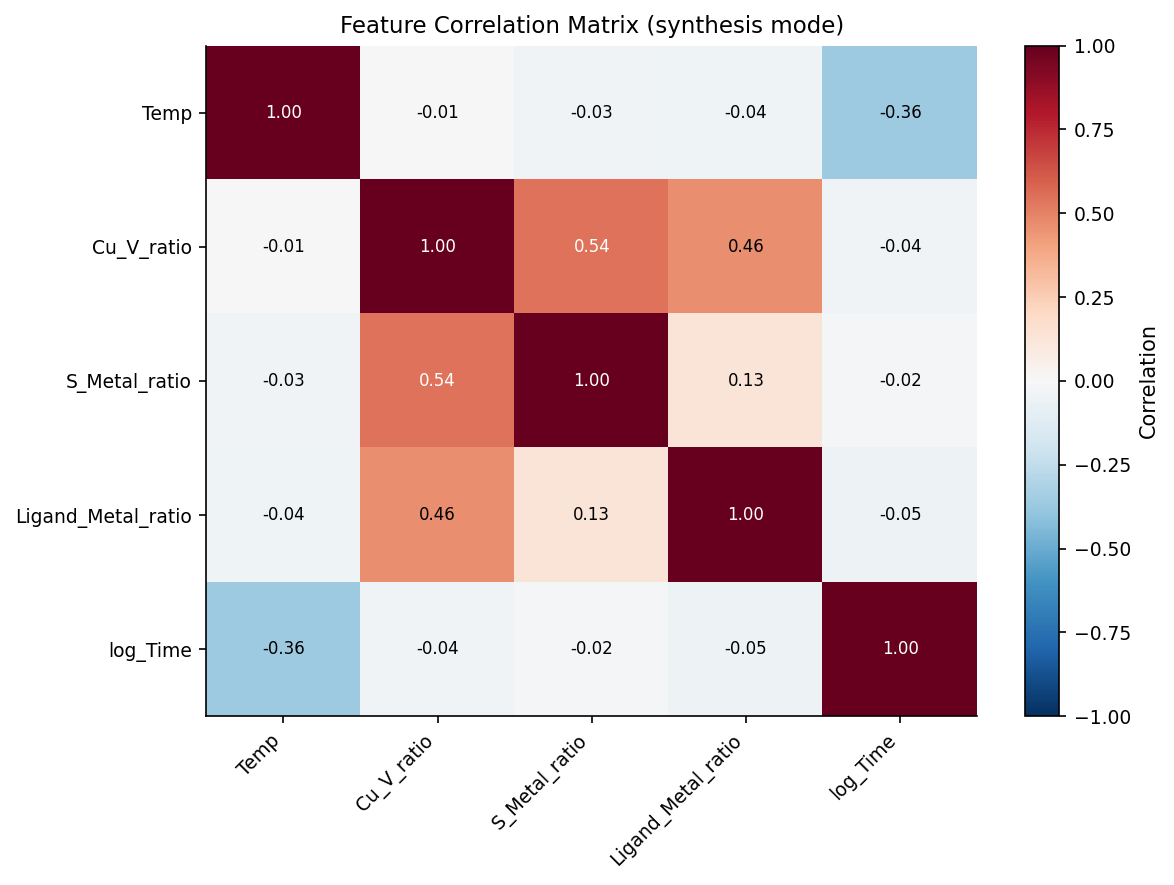

In [4]:
# =============================================================================
# DIAGNOSTIC VISUALIZATIONS
# =============================================================================
# (Already imported at top of notebook)

# Plot classifier calibration (reliability diagrams)
fig_cal = plot_classifier_calibration(optimizer)
if fig_cal:
    plt.savefig(OUTPUT_DIR / "classifier_calibration.png", dpi=150, bbox_inches='tight')
    plt.show()

# Plot feature correlation heatmap
fig_corr = plot_collinearity_heatmap(optimizer)
if fig_corr:
    plt.savefig(OUTPUT_DIR / "feature_correlations.png", dpi=150, bbox_inches='tight')
    plt.show()

## 1c. Dataset Quality Dashboard

Generate a comprehensive 4-panel dashboard summarizing dataset quality:
1. **Design Space Coverage**: Experimental diversity in parameter space
2. **Outcome Distributions**: Range of achieved Size, GSD, Squareness
3. **Dataset Composition**: Success rate and sample size adequacy
4. **Model Performance**: LOO-CV R² comparison across feature modes

✓ Dashboard saved to ../outputs/dataset_quality_dashboard.png


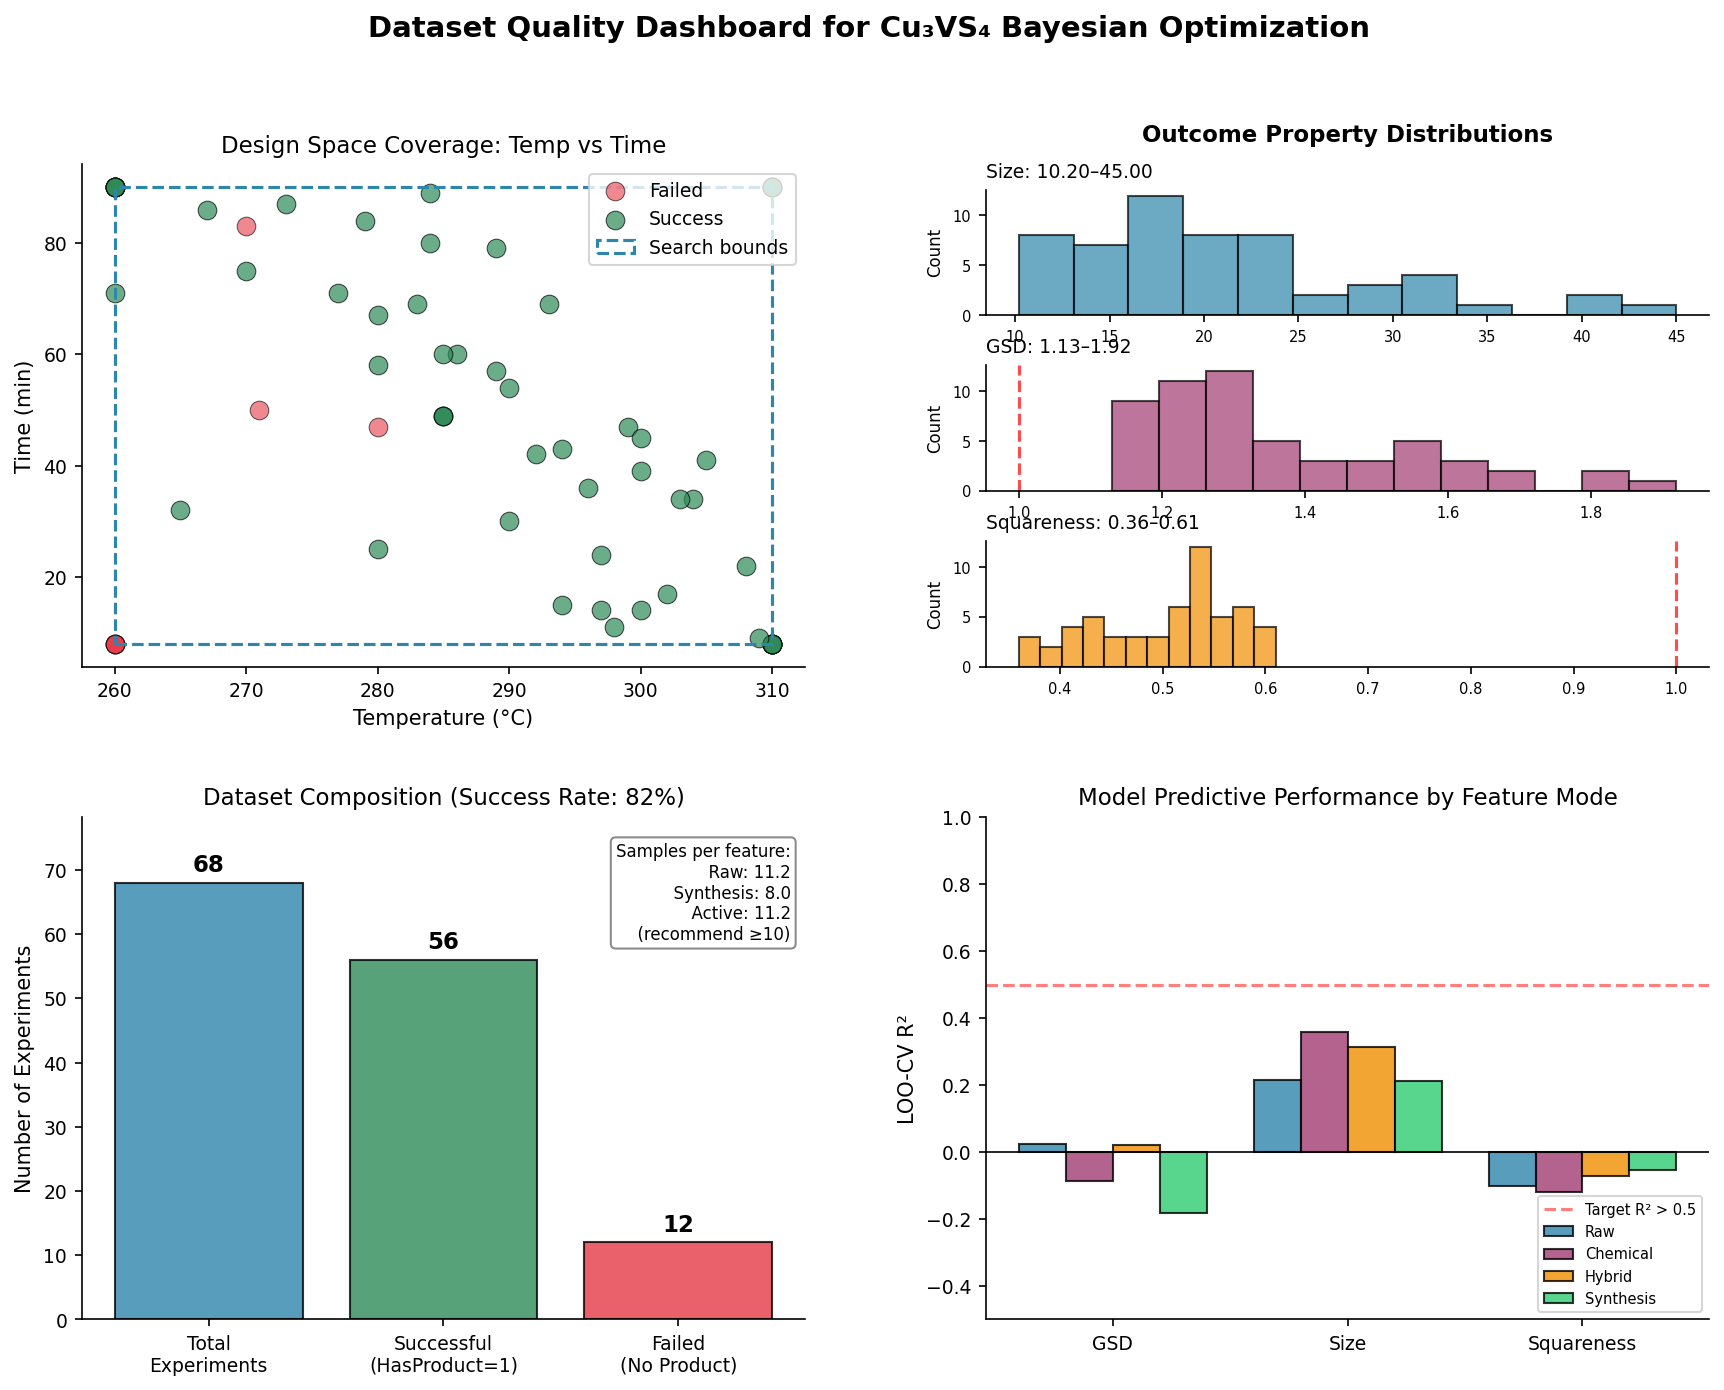


✓ Dashboard saved to: ../outputs/dataset_quality_dashboard.png


In [5]:
# =============================================================================
# DATASET QUALITY DASHBOARD (for presentations)
# =============================================================================

# Generate comprehensive dashboard
fig_dashboard = plot_dataset_quality_dashboard(
    optimizer,
    figsize=(14, 10),
    save_path=OUTPUT_DIR / "dataset_quality_dashboard.png"
)

if fig_dashboard:
    plt.show()
    print(f"\n✓ Dashboard saved to: {OUTPUT_DIR / 'dataset_quality_dashboard.png'}")

## 2. Generate Recommendations

Request synthesis recommendations for a target particle size.

In [6]:
# Set your target particle size (nm)
TARGET_SIZE = 16.0  # <-- MODIFY THIS
SIZE_TOLERANCE = 2.0  # Acceptable range: target ± tolerance

# Generate recommendations
recommendations = optimizer.recommend(
    target_size=TARGET_SIZE,
    size_tol=SIZE_TOLERANCE,
    seed=42  # For reproducibility
)

# Display nicely formatted
display_recommendations_table(recommendations)

# Also show as DataFrame
display(recommendations)


[INFO] Auto-skipping 2 existing recommendations for target 16.0nm...

GENERATING RECOMMENDATIONS
Target: 16.0 ± 2.0 nm
Base optimizer: synthesis mode
Correction applied: False

✓ Generated 2 recommendations (IDs: ['REC_007', 'REC_008'])
  These are now PENDING in the recommendation store.
  After running experiments, use complete_recommendation() to log results.

SYNTHESIS RECOMMENDATIONS

🔬 Recommendation 1: REC_007
   Conditions:
      Temp: 306.0°C | Time: 35.0 min | VOacac: 0.198 mmol
      DDT: 1.90 mL | OAm: 3.90 mL
   Predictions:
      Size: 17.1 ± 4.7 nm
      GSD: 1.279 | Squareness: 0.555
   Feasibility: 68%

🔬 Recommendation 2: REC_008
   Conditions:
      Temp: 282.0°C | Time: 77.0 min | VOacac: 0.193 mmol
      DDT: 2.90 mL | OAm: 6.00 mL
   Predictions:
      Size: 18.0 ± 4.6 nm
      GSD: 1.244 | Squareness: 0.576
   Feasibility: 64%

--------------------------------------------------------------------------------
To complete a recommendation after running the experimen

,Rank,Rec_ID,Temp,VOacac,Time,DDT,OAm,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_Squareness,P_Feasible,Extrapolation_Distance,Is_Extrapolating
0,1,REC_007,306.0,0.198,35.0,1.9,3.9,17.13,4.71,1.279,0.555,0.685,0.343287,False
1,2,REC_008,282.0,0.193,77.0,2.9,6.0,18.04,4.62,1.244,0.576,0.639,0.234579,False


## 3. View Pending Recommendations

See what recommendations are waiting for experimental results.

In [7]:
# View pending recommendations
pending = optimizer.get_pending_recommendations()
display(pending)


,Rec_ID,Date,Target_Size,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_GSD
0,REC_007,2026-03-03,16.0,306.0,35.0,0.198,1.9,3.9,17.1 ± 4.7,1.279
1,REC_008,2026-03-03,16.0,282.0,77.0,0.193,2.9,6.0,18.0 ± 4.6,1.244


## 4. Complete Recommendations (After Running Experiments)

After you run an experiment in the lab, use this to log the actual results.

In [8]:
# Uncomment and fill in when you have results:

# errors = optimizer.complete_recommendation(
#     rec_id='REC_003',      # <-- Change to your recommendation ID
#     Size=16.25,             # <-- Your measured size (nm)
#     GSD=1.58,              # <-- Your measured GSD
#     Squareness=0.67,       # <-- Your measured squareness
#     HasProduct=1,          # 1 if product formed, 0 if not
#     PhasePure=1,           # 1 if phase pure, 0 if not
#     Polymorph='cubic'      # 'cubic', 'tetragonal', 'multipod', etc.
# )

# After completing, view the model assessment:
# print_model_assessment(optimizer)


## 5. Model Assessment & Visualization

View the model's self-assessment and visualize prediction accuracy.

In [9]:
# Model self-assessment report
print_model_assessment(optimizer)



MODEL SELF-ASSESSMENT REPORT

📊 EXPERIMENT DATABASE
   Total experiments:        68
   ├─ Imported (initial):    68
   ├─ From recommendations:  0
   └─ Manual additions:      0

📋 RECOMMENDATION HISTORY
   Total recommendations:    8
   ├─ Pending:               2
   ├─ Completed:             0
   └─ Skipped:               6

📈 PREDICTION ACCURACY
   Insufficient data (0 completed, need ≥2)

🔧 ERROR CORRECTION STATUS
   Status: ⏳ INACTIVE (need 10 completed recommendations, have 0)



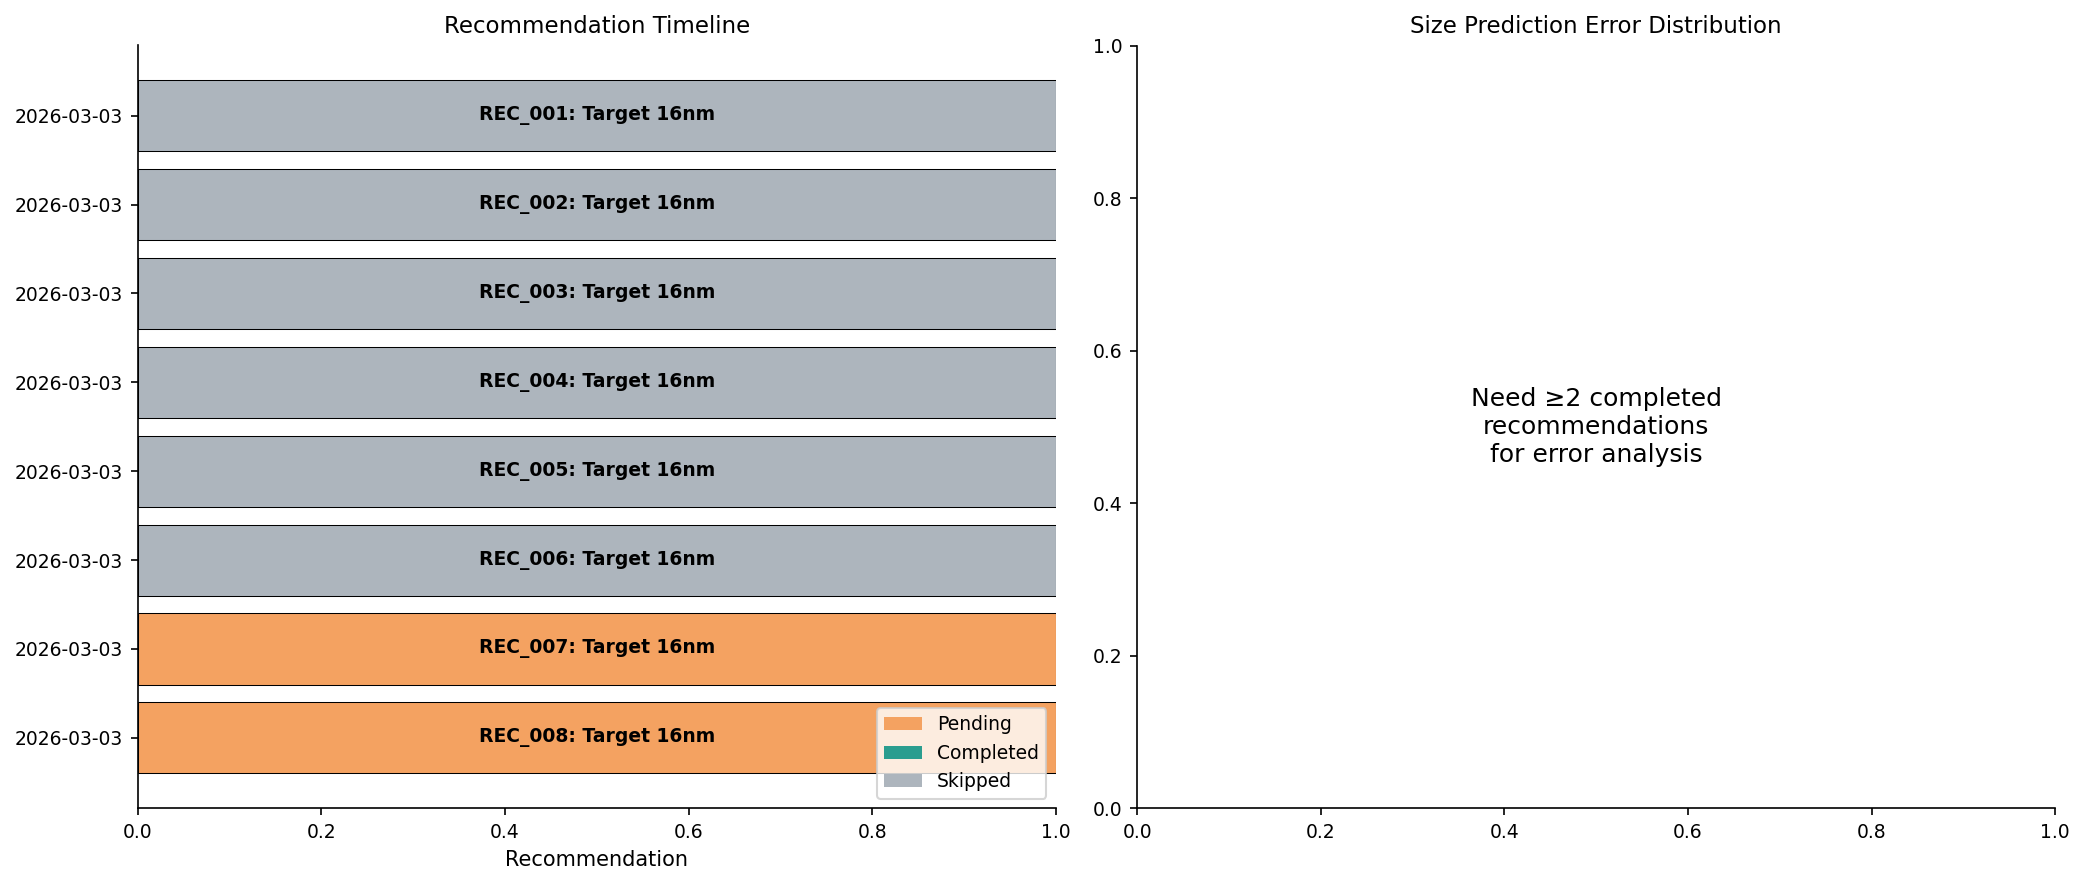

In [10]:
# Visualization: Recommendation History
fig = plot_recommendation_history(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'recommendation_history.png', dpi=300, bbox_inches='tight')
    plt.show()


In [11]:
# Visualization: Parity Plots (Predicted vs Actual)
fig = plot_parity(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'parity_plots_recommendations.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations for parity plots. Currently have 0.


In [12]:
# Visualization: Calibration Analysis
fig = plot_calibration(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'calibration_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 3 completed recommendations for calibration analysis. Have 0.


## 6. Additional Visualizations

### Error Correction Impact
Compare predictions with vs without error correction to see the value of self-validation.

### Target Achievement Tracking
Track how well recommendations achieve target sizes over time.

### Feature Importance
Visualize which synthesis parameters matter most for each property.

In [13]:
# Visualization: Error Correction Impact (compares with vs without correction)
fig = plot_error_correction_impact(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'error_correction_impact.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations. Have 0.


In [14]:
# Visualization: Target Achievement Tracking
fig = plot_target_achievement(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'target_achievement.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 2 completed recommendations. Have 0.


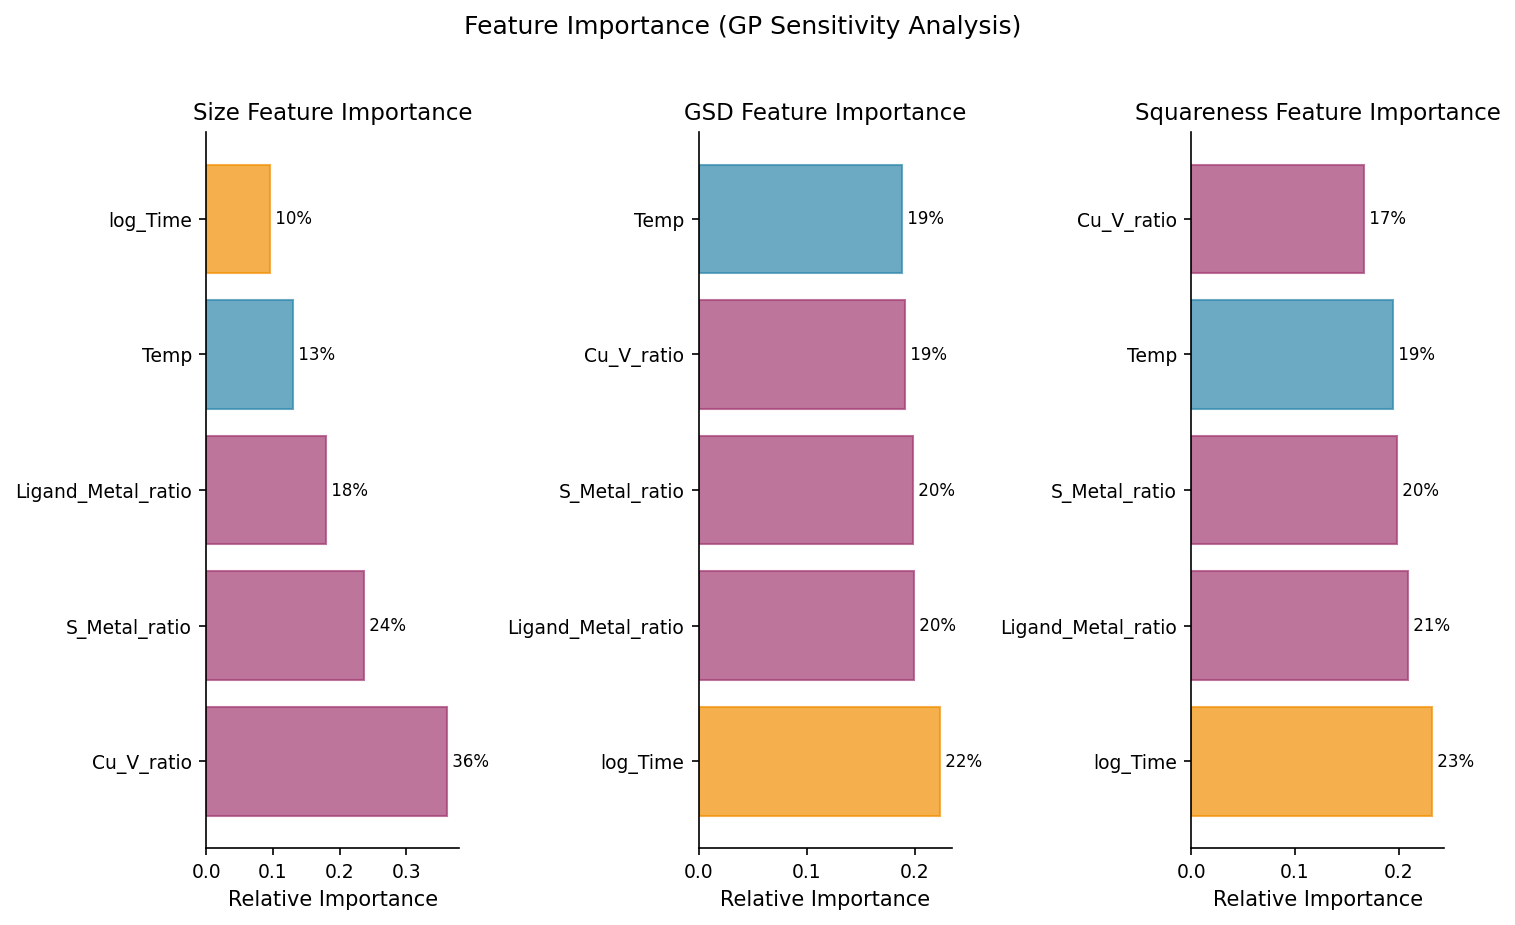

In [15]:
# Visualization: Feature Importance
fig = plot_feature_importance(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


### Data & optimization quality

Additional plots to analyze **data quality** and **optimization algorithm quality**:

- **LOO residuals**: Parity (actual vs LOO predicted) and residuals vs predicted for Size, GSD, Squareness — checks model fit and homoscedasticity.
- **Property correlations**: Pairwise scatter of Size, GSD, Squareness — shows trade-offs and correlations in your data.
- **Acquisition slice**: 2D heatmap of acquisition over two parameters (e.g. Temp vs log_Time) — shows where the algorithm is searching.
- **Recommendation regret**: |actual − target| over completed recommendations — tracks optimization quality over time.

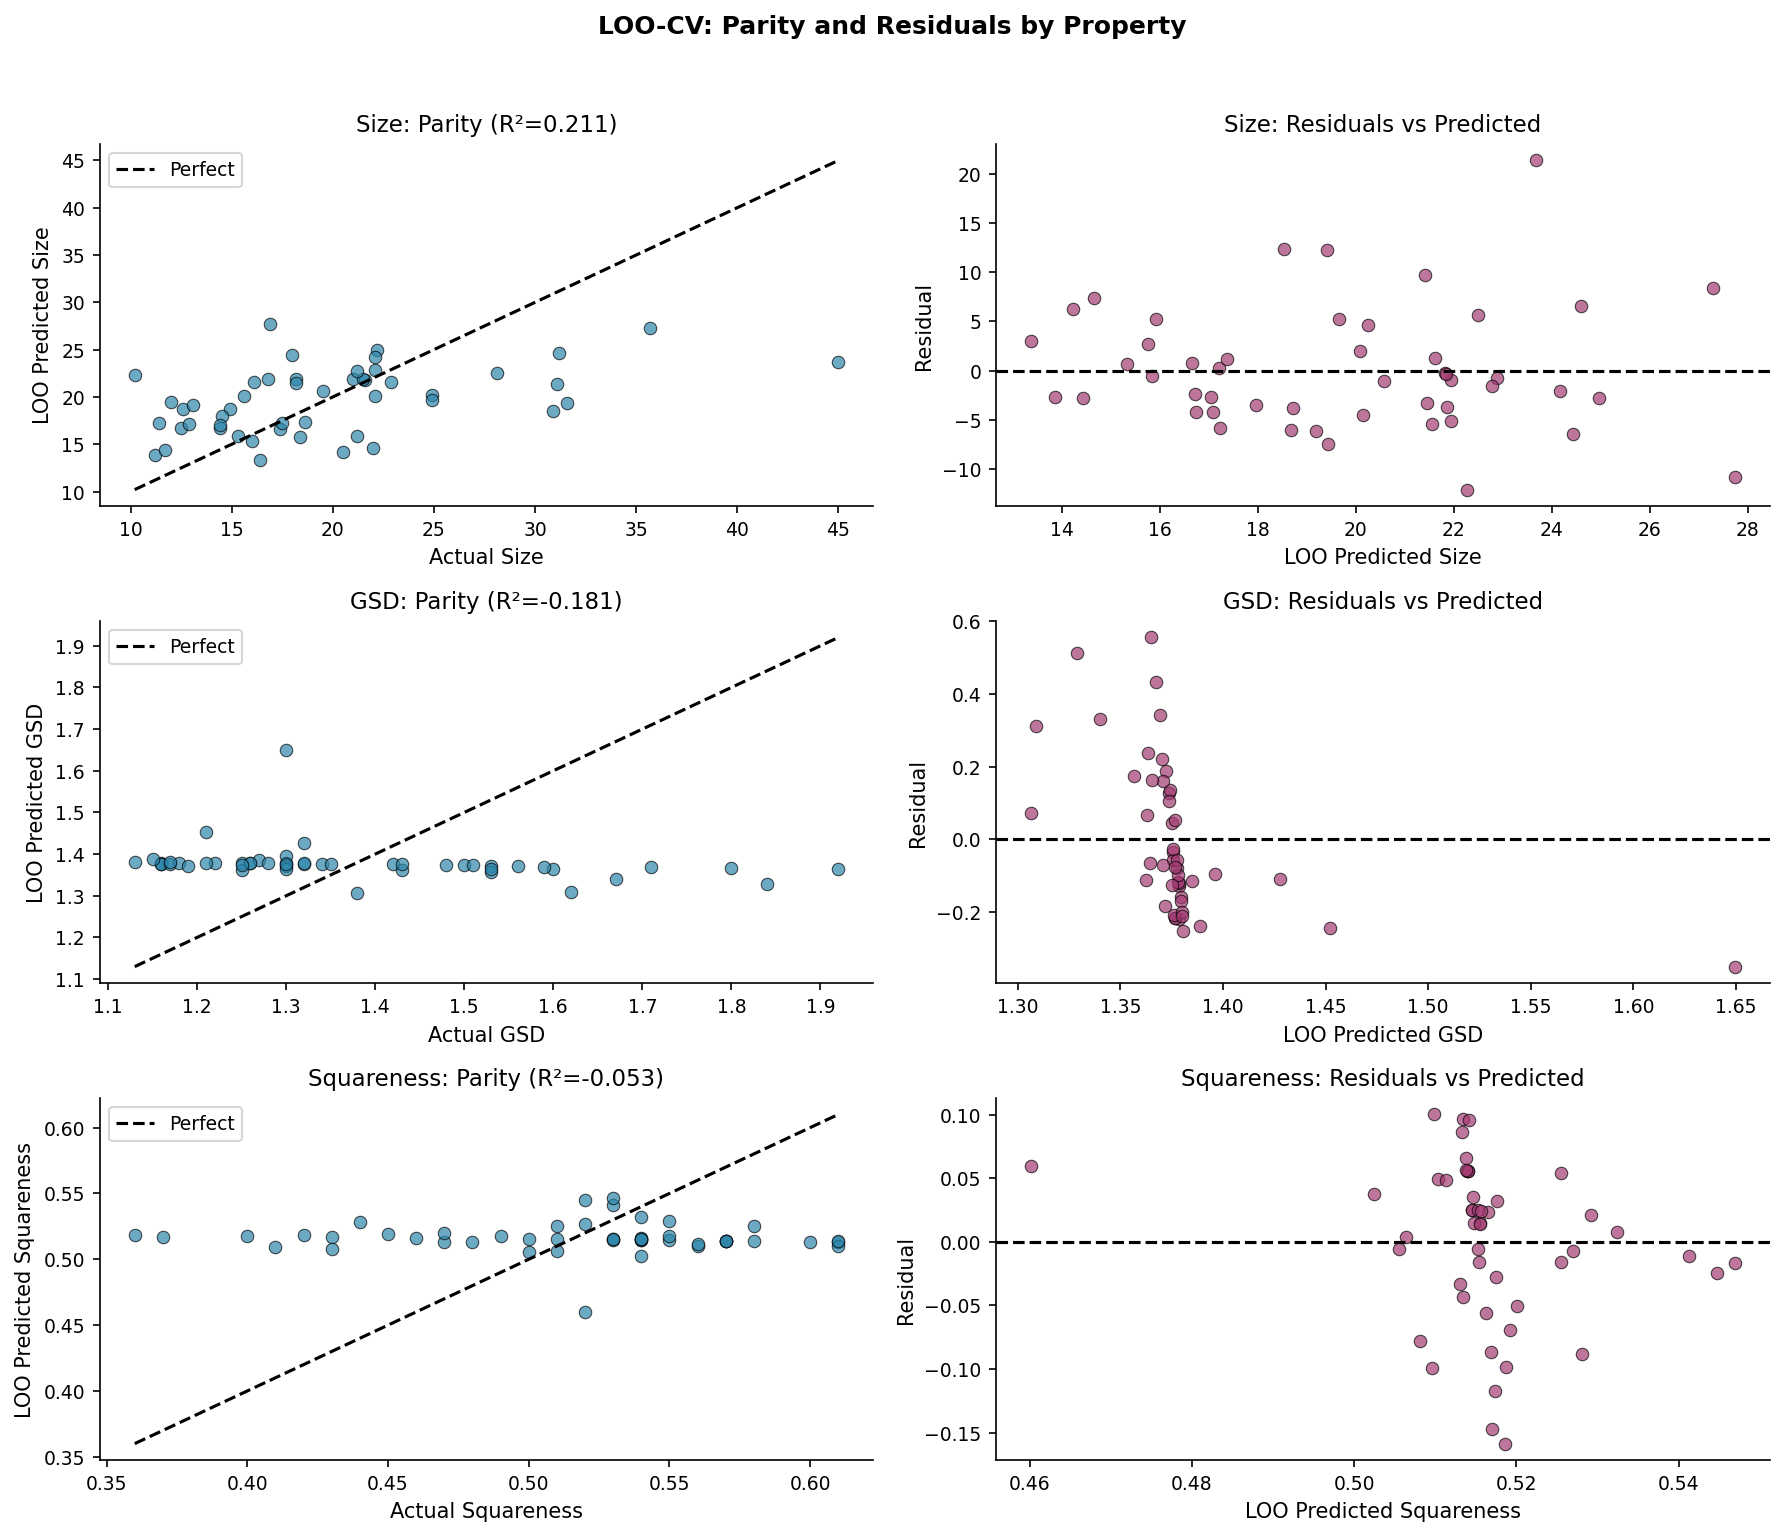

In [16]:
# LOO-CV residuals: parity and residuals vs predicted (data quality)
fig = plot_loo_residuals(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'loo_residuals.png', dpi=300, bbox_inches='tight')
    plt.show()

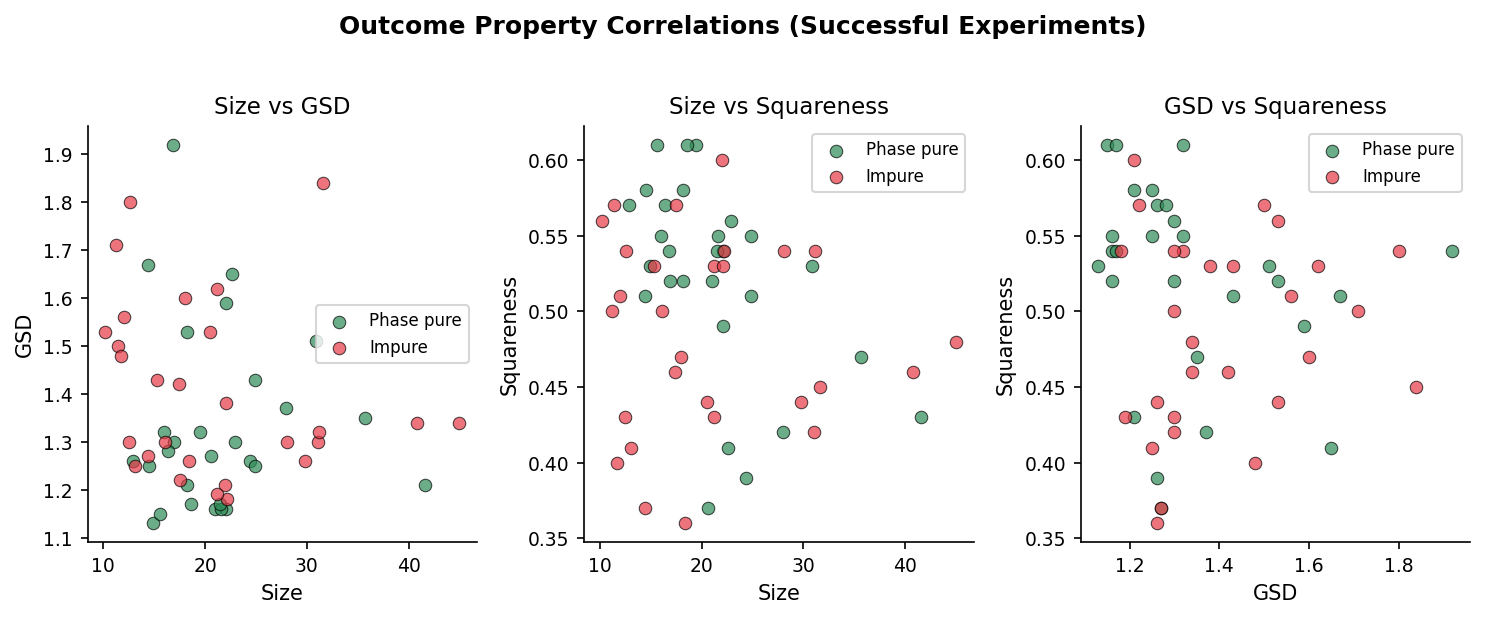

In [17]:
# Property correlations: Size vs GSD vs Squareness (data quality)
fig = plot_property_correlations(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'property_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

In [18]:
# Visualization: Error Learning Progress
fig = plot_error_learning_progress(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'learning_progress.png', dpi=300, bbox_inches='tight')
    plt.show()


Need at least 3 completed recommendations. Have 0.


In [19]:
# Simple regret over completed recommendations (optimization quality)
fig = plot_recommendation_regret(optimizer)
if fig:
    plt.savefig(OUTPUT_DIR / 'recommendation_regret.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Need at least 2 completed recommendations to plot regret.")

Need at least 2 completed recommendations to plot regret.


### When have I hit maximum optimization? (especially across sizes)

Use the **convergence summary** to see overall and **per target-size-band** performance (success rate within tolerance, mean |error| from target). If the **last N** completed recommendations have similar or worse error than overall and success rate is already high, you may be at a plateau. See `docs/development/CONVERGENCE_ACROSS_SIZES.md` for full guidance.

In [20]:
# Convergence check: overall, by target size band, and last N recommendations
print_optimization_convergence_summary(optimizer, last_n=10, size_band_nm=5.0)


OPTIMIZATION CONVERGENCE SUMMARY

  Completed recommendations: 0
  → Need at least 2 completed recs to assess convergence.


## 6. Additional Operations

### Add Manual Experiments
Add experiments you designed yourself (not from recommendations).

### Test Predictions
Predict outcomes for specific conditions without making a recommendation.

In [21]:
# Add a manual experiment (not from recommendation)
# Uncomment and fill in:

# exp_id = optimizer.add_manual_experiment(
#     Temp=285.0,
#     Time=30.0,
#     VOacac=0.25,
#     DDT=3.0,
#     OAm=4.0,
#     Size=19.5,
#     GSD=1.30,
#     Squareness=0.62,
#     HasProduct=1,
#     PhasePure=1,
#     Polymorph='cubic'
# )
# print(f"Added: {exp_id}")


In [22]:
# Test predictions for specific conditions (without making a recommendation)
result = optimizer.predict_from_conditions(
    Temp=285.0,
    Time=30.0,
    VOacac=0.20,
    DDT=3.0,
    OAm=4.5,
    verbose=True
)



PREDICTION RESULTS

Conditions:
  Temp: 285.0°C, Time: 30.0 min, VOacac: 0.2 mmol
  DDT: 3.0 mL, OAm: 4.5 mL

Base Optimizer: synthesis mode

Predictions (with error correction):
  Size:       19.66 ± 4.99 nm
  GSD:        1.377 ± 0.218
  Squareness: 0.514 ± 0.067

Feasibility:
  P(Product):    0.886
  P(Phase Pure): 0.753
  P(Cubic):      0.888
  P(Feasible):   0.592


In [23]:
base = optimizer.base_optimizer
for name, gp in [("Size", base.gp_size), ("GSD", base.gp_gsd), ("Squareness", base.gp_sq)]:
    print(f"\n{name} fitted kernel:")
    print(f"  {gp.kernel_}")
    print(f"  Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}")


Size fitted kernel:
  1.15**2 * Matern(length_scale=1.88, nu=2.5) + WhiteKernel(noise_level=0.326)
  Log-marginal-likelihood: -63.907

GSD fitted kernel:
  1.08**2 * Matern(length_scale=0.3, nu=2.5) + WhiteKernel(noise_level=0.01)
  Log-marginal-likelihood: -67.784

Squareness fitted kernel:
  0.992**2 * Matern(length_scale=0.311, nu=2.5) + WhiteKernel(noise_level=0.0664)
  Log-marginal-likelihood: -67.834


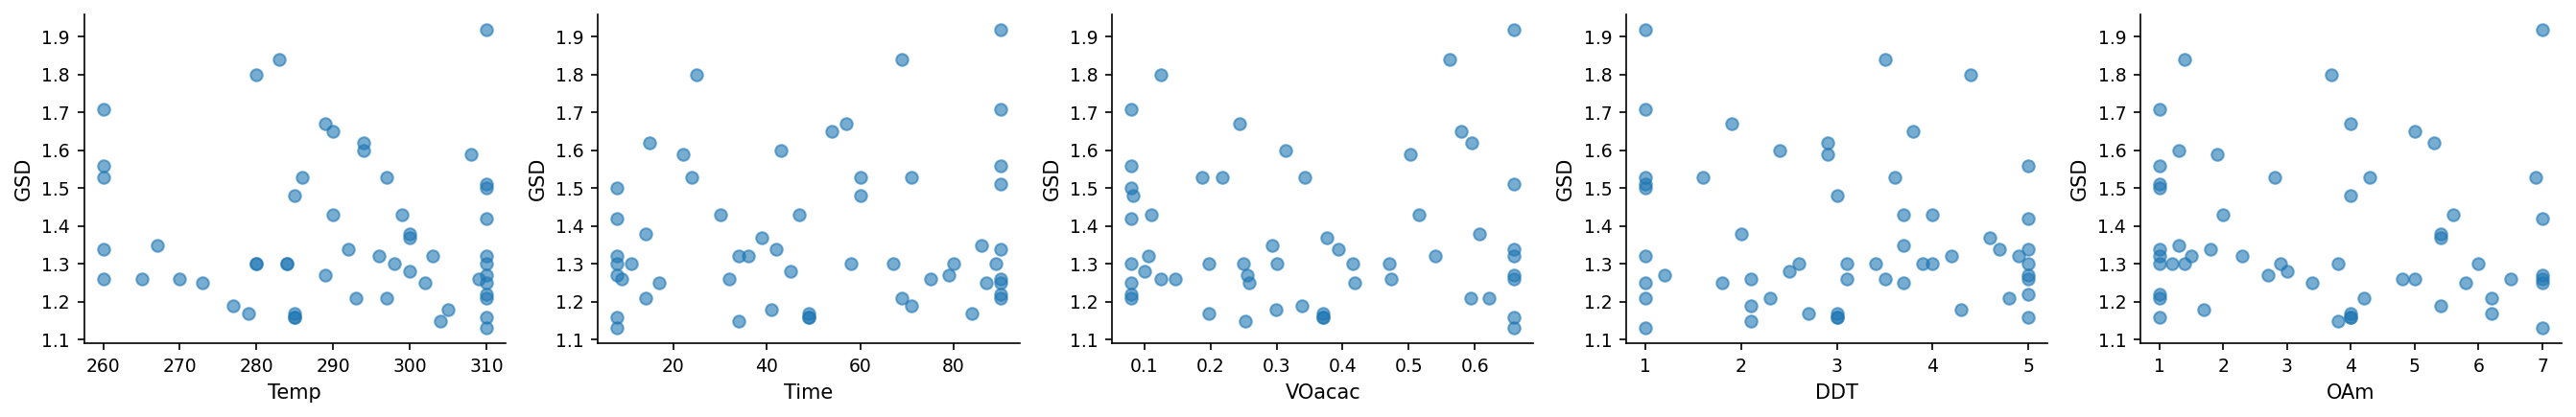

In [24]:
df_success = optimizer.base_optimizer.df_success
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, col in zip(axes, ['Temp', 'Time', 'VOacac', 'DDT', 'OAm']):
    ax.scatter(df_success[col], df_success['GSD'], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('GSD')
plt.tight_layout()